## Validation of PVade against DuraMAT experimental campaign ##

In [294]:
import pandas as pd
import numpy as np
import yaml
import pickle
import importlib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# spectra
from scipy.signal import welch
from numpy import hanning
import math

# from postprocessing_functions import *
# importlib.reload(postprocessing_functions) # to reload functions without restarting the notebook

In [295]:
pwd

'/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing'

In [296]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
# casepath = 'y20m_turbinflow_duramat_validation/'

# casepath = 'halfwing_turbinflow_duramat_validation_40deg/'
# exp_data_fn = 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv'

casepath = 'halfwing_turbinflow_duramat_validation_neg40deg/'
exp_data_fn = 'DuraMAT_tiltneg40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_-10.0deg/'
# exp_data_fn = 'DuraMAT_tiltneg10deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_10.0deg/'
# exp_data_fn = 'DuraMAT_tilt10deg_turbulent_inflow_10min_timeseries.csv'

tilts = [-40.0]
# panel_span = 10.0
# panel_chord = 4.1

### Step 1: read in csv data (lift and drag, acceleration at NE corner of panel) ###

In [297]:
# read in lift and drag
output_dir=parentdir+'output/'+casepath
tmp = pd.read_csv(output_dir+'solution/lift_and_drag.csv')
tmp.rename(columns={'#Time': 'Time'}, inplace=True)
tmp = tmp.set_index('Time')
loadsdata = tmp

# read in accelerations
# tmp2 = pd.read_csv(output_dir+'solution/accel_pos.csv')
# loadsdata['accel-x'] = tmp2['#x-pos'].values
# loadsdata['accel-y'] = tmp2['y-pos'].values
# loadsdata['accel-z'] = tmp2['z-pos'].values
# loadsdata['accel-magnitude'] = loadsdata['accel-x']**2 + loadsdata['accel-y']**2 + loadsdata['accel-z']**2

# clean up
del tmp
# del tmp2

loadsdata

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0
Time,,,,,,
0.006,86712.453080,-125.283443,-103108.324100,46.937888,-0.067817,-55.813055
0.012,13591.253680,-46.930412,-14334.815900,7.357014,-0.025404,-7.759508
0.018,-1563.924561,-16.003274,3803.752170,-0.846560,-0.008663,2.058990
0.024,3116.790079,-9.712742,-2980.896969,1.687134,-0.005258,-1.613575
0.030,5269.657668,-14.777142,-5564.367039,2.852492,-0.007999,-3.012020
...,...,...,...,...,...,...
29.772,1608.309582,-9.953092,-1824.304424,0.870586,-0.005388,-0.987505
29.778,1608.599462,-10.252970,-1822.744311,0.870743,-0.005550,-0.986661
29.784,1495.948498,-7.884720,-1699.440783,0.809764,-0.004268,-0.919916


### Step 2: Read in post-processed velocity data from PVade sim ###

In [298]:
# read input parameters
with open(output_dir+'input_params.yaml', 'r') as file:
    params = yaml.safe_load(file)

print('tracker_angle = {} m/s'.format(params['pv_array']['tracker_angle']))
dt_sim = params['solver']['dt']
dt_xdmf = params['solver']['save_xdmf_interval']
panel_span = params['pv_array']['panel_span']
panel_chord = params['pv_array']['panel_chord']
tf = params['solver']['t_final']

tracker_angle = -40.0 m/s


In [299]:
# read velocity data
readdata = {}
coords = {}
    
for j, tilt in enumerate(tilts):
    readdata[tilt] = {}
    coords[tilt] = {}

    pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+pkl_fname

    print('reading from', pkl_path)

    try:
        with open(pkl_path, 'rb') as f:
            # try:
            readrawdata = pickle.load(f)
                
            # print(rawdata[winddir][tilt][case].keys())
            readdata[tilt]['u'] = readrawdata['u']
            readdata[tilt]['v'] = readrawdata['v']
            readdata[tilt]['w'] = readrawdata['w']
            print('vel data nt, nx, ny, nz = ', np.shape(readdata[tilt]['u']))
    except Exception as e:
        print(f"Error loading pickle file: {e}")

# i think coords are only different for each tilt angle
if 'X' in readrawdata.keys():
    tmpX = readrawdata['X']
    print('coord nx, ny, nz = ', np.shape(tmpX))
    del tmpX

    coords[tilt]['X'] = readrawdata['X']
    coords[tilt]['Y'] = readrawdata['Y']
    coords[tilt]['Z'] = readrawdata['Z']
                        
del readrawdata

ndim = len(np.shape(readdata[tilt]['u']))

reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_-40.0.pkl
vel data nt, nx, ny, nz =  (2484, 131, 65, 50)
coord nx, ny, nz =  (131, 65, 50)


In [300]:
# create dataframe from velocity data
nt = np.shape(readdata[tilt]['u'])[0]
time_xdmf = np.arange(dt_xdmf, tf+dt_xdmf, dt_xdmf)[0:nt] #np.linspace(dt_xdmf, tf, nt)

xi = coords[tilt]['X'][:,0,0]
yi = coords[tilt]['Y'][0,:,0]
zi = coords[tilt]['Z'][0,0,:]

# velocity signal at sonic location
# [xloc, yloc, zloc] = [-12.36, 0.0, 2.23]
[xloc, yloc, zloc] = [-12.36, 4.5, 2.23]
i = int(np.argmin(np.abs(xi - xloc)))
j = int(np.argmin(np.abs(yi - yloc)))
k = int(np.argmin(np.abs(zi - zloc)))
# print(f'sonic loc indices = {i, j, k}')

vel_data = pd.DataFrame(index=time_xdmf)
# for comp in ['u', 'v', 'w']:
#     vel_data[comp+' (m/s) at inlet'] = readdata[tilt][comp][:,0,j,k]
# for comp in ['u', 'v', 'w']:
#     vel_data[comp+' (m/s) at sonic'] = readdata[tilt][comp][:,i,j,k]
for comp in ['u', 'v', 'w']:
    vel_data[comp+' (m/s)'] = readdata[tilt][comp][:,0,j,k]
vel_data

,u (m/s),v (m/s),w (m/s)
0.012,NaN,NaN,NaN
0.024,NaN,NaN,NaN
0.036,NaN,NaN,NaN
0.048,NaN,NaN,NaN
0.060,NaN,NaN,NaN
...,...,...,...
29.760,9.163678,-1.737442,0.450726
29.772,9.164227,-1.728365,0.637506
29.784,8.939904,-1.955931,1.420380
29.796,8.570486,-2.107441,1.543289


In [301]:
# merge sim data
sim_data = pd.merge(loadsdata, vel_data, left_index=True, right_index=True, how='inner')
sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,u (m/s),v (m/s),w (m/s)
0.012,13591.253680,-46.930412,-14334.815900,7.357014,-0.025404,-7.759508,NaN,NaN,NaN
0.024,3116.790079,-9.712742,-2980.896969,1.687134,-0.005258,-1.613575,NaN,NaN,NaN
0.048,11580.946420,-28.854834,-13360.225980,6.268825,-0.015619,-7.231958,NaN,NaN,NaN
0.060,3849.894467,-5.998936,-4146.442274,2.083967,-0.003247,-2.244490,NaN,NaN,NaN
0.072,5123.474318,-3.591164,-5861.811638,2.773362,-0.001944,-3.173028,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
29.724,1561.937162,-9.553585,-1775.302572,0.845484,-0.005171,-0.960980,9.618858,-1.344038,-1.174057
29.736,1544.995133,-8.994323,-1754.995430,0.836314,-0.004869,-0.949988,9.938065,-1.495744,-1.138473
29.748,1444.028047,-6.496085,-1644.861581,0.781660,-0.003516,-0.890372,9.291410,-1.642550,-0.055824
29.760,1448.733779,-6.651869,-1652.325478,0.784207,-0.003601,-0.894412,9.163678,-1.737442,0.450726


In [302]:
# calculate lift and drag coeff
sfc_area = panel_span * panel_chord
sim_data['vel_mag (m/s)'] = (sim_data['u (m/s)']**2 + sim_data['v (m/s)']**2 + sim_data['w (m/s)']**2)**0.5
sim_data['fx_nd_calc'] = (sim_data['fx_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)
sim_data['fz_nd_calc'] = (sim_data['fz_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)

### Step 3: read in measurement data from DuraMAT ###

In [303]:
# read in experimental data
def read_csv_data(raw_data):
    # read csv
    exp_data = raw_data
    
    # construct time index
    tmp = (exp_data.index[1]-exp_data.index[0])
    dt_sonic1 = round(tmp.total_seconds(), 3)
    tf_sonic1 = len(exp_data) * dt_sonic1 # final time [s]
    t_sonic1 = np.arange(0.0, tf_sonic1, dt_sonic1)

    exp_data['u (m/s)'] = -1.0*exp_data['u (m/s)'] # to make it positive from the west
    exp_data['Time'] = t_sonic1
    exp_data = exp_data.set_index('Time')

    return tf_sonic1, exp_data
    
raw_exp_data = pd.read_csv(exp_data_fn, index_col='Time')
raw_exp_data.index = pd.to_datetime(raw_exp_data.index)

tf_sonic1, exp_data = read_csv_data(raw_exp_data)
dt_exp = exp_data.index[1]-exp_data.index[0]

# cut sonic data to time period simulated
if tilt == -40.0:
    tstart = 250.0
elif tilt == 40.0:
    tstart = 0.0
elif tilt == -10.0:
    tstart = 280.0
elif tilt == 10.0:
    tstart = 100.0

exp_data = exp_data[exp_data.index >= tstart]
exp_data = exp_data[exp_data.index <= sim_data.index[-1]+tstart]
exp_data.index = exp_data.index - tstart
exp_data = exp_data[exp_data.index > 0.0]

exp_data

,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN)
Time,,,,,,,,,,,,,
0.02,6.688102,285.27142,6.449972,1.761056,-0.165087,9.764428,-40.448708,1.395001,-1.250874,2.176431,-2.593769,2.196677,-2.576645
0.04,6.688065,285.27210,6.449918,1.761120,-0.165003,9.764052,-40.448486,1.390216,-1.236183,2.168965,-2.584872,2.189131,-2.567815
0.06,6.687864,285.27036,6.449776,1.760874,-0.165033,9.764128,-40.447380,1.409820,-1.235368,2.199550,-2.621322,2.219951,-2.604068
0.08,6.688227,285.27658,6.449938,1.761668,-0.164962,9.764428,-40.452953,1.438299,-1.265117,2.243983,-2.674274,2.265054,-2.656451
0.10,6.688403,285.27698,6.450090,1.761759,-0.165123,9.763300,-40.451080,1.457942,-1.292085,2.274628,-2.710796,2.295899,-2.692805
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,8.311738,275.25507,8.165381,0.751021,-1.359231,9.519747,-40.451023,2.233295,-1.579532,3.484306,-4.152434,3.516885,-4.124878
29.72,8.312077,275.25522,8.165641,0.751065,-1.359720,9.519622,-40.447880,2.322052,-1.670582,3.622783,-4.317464,3.656421,-4.289013
29.74,8.312278,275.24738,8.165965,0.749968,-1.359605,9.518092,-40.449093,2.383642,-1.731545,3.718873,-4.431980,3.753497,-4.402695


In [304]:
# calculate lift and drag force coefficients
exp_data['Drag Coefficient'] = (exp_data['Drag force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)
exp_data['Lift Coefficient'] = (exp_data['Lift force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)

In [305]:
# interpolate to 50 Hz to match duramat loads signals
new_time_index = exp_data.index #exp_data[exp_data.index>0.0].index
interp_sim_data = pd.DataFrame(index=new_time_index)
for col in sim_data.columns:
    interpolator = interp1d(sim_data.index, sim_data[col].values, kind='linear')  # Use 'linear' or 'cubic' as needed
    interp_sim_data[col] = interpolator(new_time_index)

interp_sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,u (m/s),v (m/s),w (m/s),vel_mag (m/s),fx_nd_calc,fz_nd_calc
Time,,,,,,,,,,,,
0.02,6608.277946,-22.118632,-6765.536613,3.577094,-0.011973,-3.662219,NaN,NaN,NaN,NaN,NaN,NaN
0.04,8759.560973,-22.474137,-9900.449643,4.741594,-0.012165,-5.359163,NaN,NaN,NaN,NaN,NaN,NaN
0.06,3849.894467,-5.998936,-4146.442274,2.083967,-0.003247,-2.244490,NaN,NaN,NaN,NaN,NaN,NaN
0.08,6359.595178,0.193051,-7278.797921,3.442481,0.000104,-3.940050,NaN,NaN,NaN,NaN,NaN,NaN
0.10,2492.741651,10.863081,-2823.844580,1.349334,0.005880,-1.528561,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,1597.253405,-10.722196,-1814.344476,0.864601,-0.005804,-0.982114,8.440685,-0.659283,-0.319620,8.502584,0.856096,-0.972354
29.72,1563.211635,-9.942756,-1776.554213,0.846174,-0.005382,-0.961658,9.373635,-1.228083,-0.976506,9.507926,0.648827,-0.737367
29.74,1511.339438,-8.161577,-1718.284147,0.818096,-0.004418,-0.930116,9.722513,-1.544679,-0.777590,9.888063,0.577565,-0.656706


In [306]:
# merge dataframes
alldata = {}

alldata['exp'] = exp_data.copy()
alldata['sim'] = sim_data.copy()
alldata['sim_interp'] = interp_sim_data.copy()

# adjustments
alldata['exp'] = alldata['exp'].rename(columns={'3D wind speed (m/s)':'vel_mag (m/s)'})

for comp in ['fx','fy','fz']:
    alldata['sim'][comp+'_0'] = alldata['sim'][comp+'_0']/1000
    alldata['sim_interp'][comp+'_0'] = alldata['sim_interp'][comp+'_0']/1000

for key in ['sim','sim_interp']:
    alldata[key] = alldata[key].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)',
                                               'fx_nd_calc':'Drag Coefficient','fz_nd_calc':'Lift Coefficient'})
    # alldata['sim'] = alldata['sim'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})
    # alldata['sim_interp'] = alldata['sim_interp'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})

alldata['sim']

,Drag force (kN),Lateral force (kN),Lift force (kN),fx_nd_0,fy_nd_0,fz_nd_0,u (m/s),v (m/s),w (m/s),vel_mag (m/s),Drag Coefficient,Lift Coefficient
0.012,13.591254,-0.046930,-14.334816,7.357014,-0.025404,-7.759508,NaN,NaN,NaN,NaN,NaN,NaN
0.024,3.116790,-0.009713,-2.980897,1.687134,-0.005258,-1.613575,NaN,NaN,NaN,NaN,NaN,NaN
0.048,11.580946,-0.028855,-13.360226,6.268825,-0.015619,-7.231958,NaN,NaN,NaN,NaN,NaN,NaN
0.060,3.849894,-0.005999,-4.146442,2.083967,-0.003247,-2.244490,NaN,NaN,NaN,NaN,NaN,NaN
0.072,5.123474,-0.003591,-5.861812,2.773362,-0.001944,-3.173028,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
29.724,1.561937,-0.009554,-1.775303,0.845484,-0.005171,-0.960980,9.618858,-1.344038,-1.174057,9.783009,0.609101,-0.692306
29.736,1.544995,-0.008994,-1.754995,0.836314,-0.004869,-0.949988,9.938065,-1.495744,-1.138473,10.114272,0.563675,-0.640291
29.748,1.444028,-0.006496,-1.644862,0.781660,-0.003516,-0.890372,9.291410,-1.642550,-0.055824,9.435644,0.605345,-0.689536
29.760,1.448734,-0.006652,-1.652325,0.784207,-0.003601,-0.894412,9.163678,-1.737442,0.450726,9.337818,0.620109,-0.707254


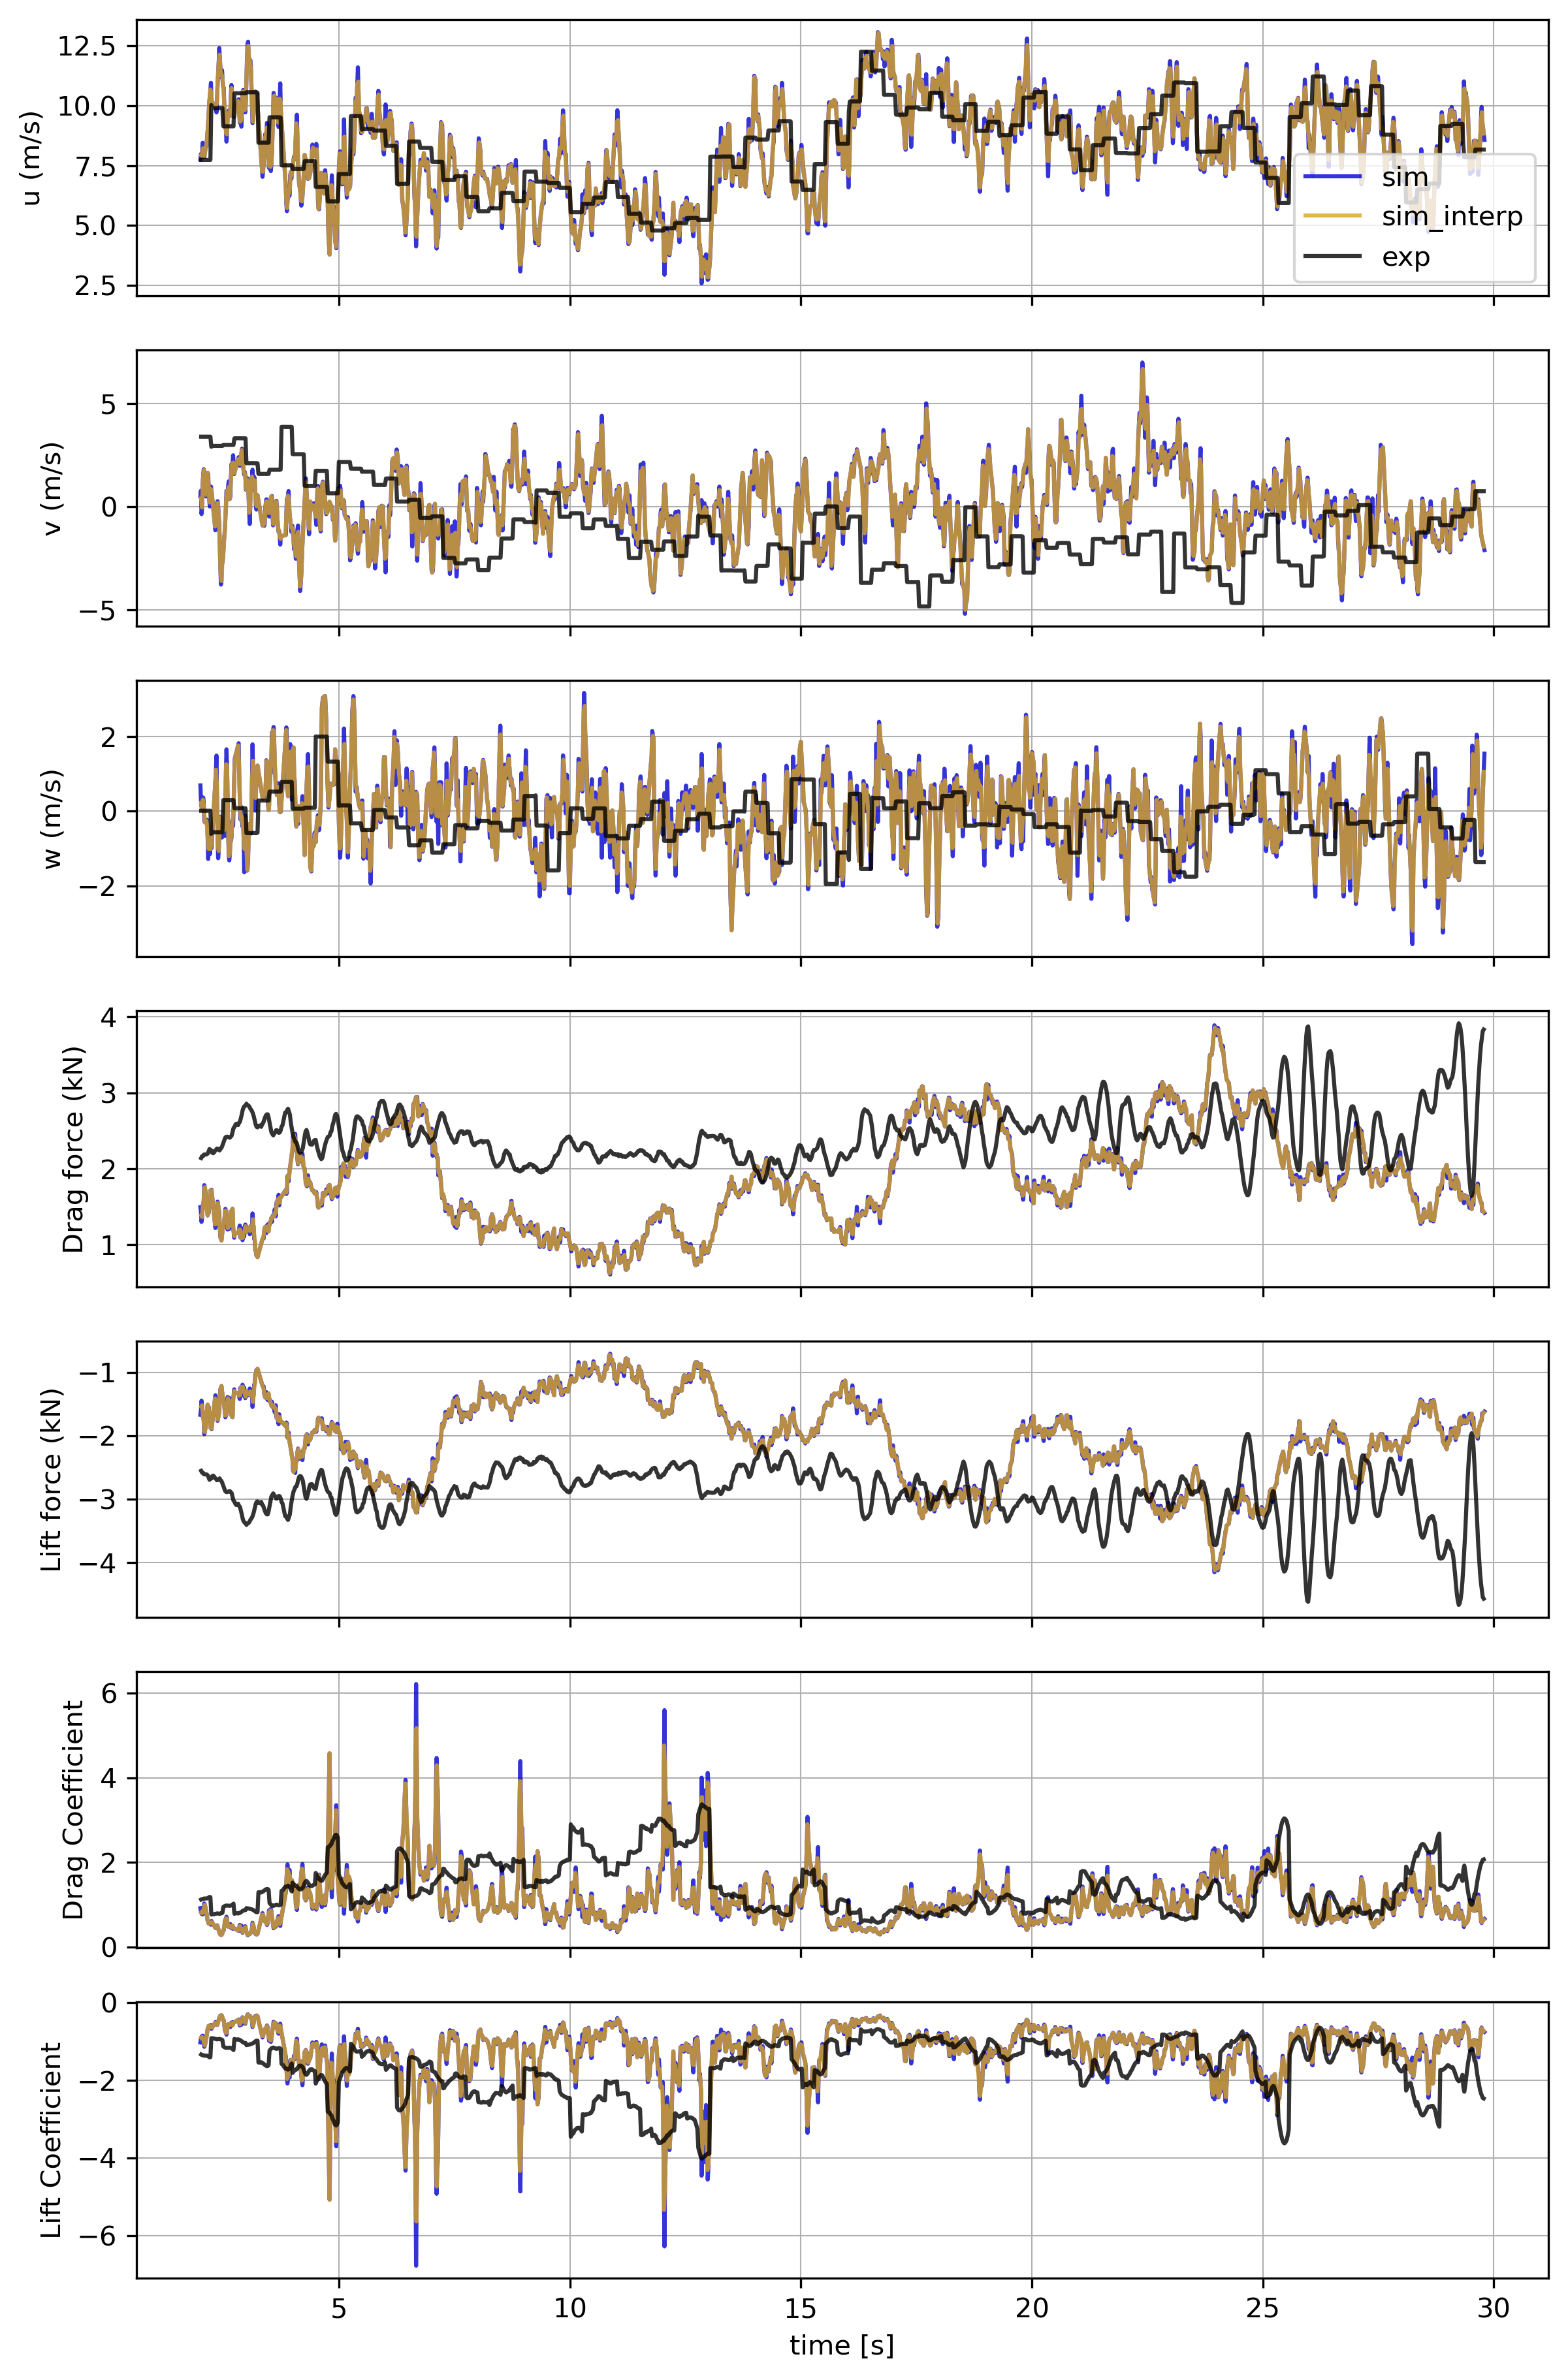

In [307]:
# plot velocity signals and drag and lift force
comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)

for comp,ax in zip(comps, axs.ravel()):
    for var in vars:
        pltdata = alldata[var][comp][alldata[var][comp].index > 2.0]
        ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

In [308]:
# compute errors
keys = ['sim_interp']
comps = ['u (m/s)','v (m/s)','w (m/s)','vel_mag (m/s)','Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
baseline = 'exp'

error_list = []
error_df = {}

mean_abs_err = {}
mean_perc_err = {}
for key in keys:
    mean_abs_err[key] = {}
    mean_perc_err[key] = {}
    for comp in comps:
        mean_abs_err[key][comp] = round(float(np.nanmean(alldata[key][comp].values - alldata[baseline][comp].values)),4)
        mean_perc_err[key][comp] = 100*round(float(np.nanmean((alldata[key][comp].values - alldata[baseline][comp].values)/alldata[baseline][comp].values)),3)

        # Append results as a dictionary to the error list
        error_list.append({
            'Variable': comp,
            'Mean_Absolute_Error': mean_abs_err[key][comp],
            'Mean_Percent_Error [%]': mean_perc_err[key][comp]
        })

    error_df[key] = pd.DataFrame(error_list).set_index('Variable')
error_df[key]

,Mean_Absolute_Error,Mean_Percent_Error [%]
Variable,,
u (m/s),-0.0662,-0.6
v (m/s),1.1795,-121.9
w (m/s),0.1693,713.1
vel_mag (m/s),-0.1328,-1.3
Drag force (kN),-0.5277,-21.0
Lift force (kN),0.8112,-27.3
Drag Coefficient,-0.3017,-15.1
Lift Coefficient,0.4613,-21.8


,Var,Mean,Median,Max,Min,Std Dev
Key,,,,,,
exp,Drag force (kN),2.437,2.398,3.915,1.644,0.351
sim,Drag force (kN),1.895,1.806,3.889,0.608,0.646
sim_interp,Drag force (kN),1.871,1.783,3.860,0.625,0.646
exp,Lift force (kN),-2.904,-2.857,-1.959,-4.666,0.418
sim,Lift force (kN),-2.075,-1.988,-0.705,-4.151,0.674
sim_interp,Lift force (kN),-2.051,-1.964,-0.723,-4.123,0.675
exp,Drag Coefficient,1.399,1.260,3.375,0.543,0.609
sim,Drag Coefficient,1.083,0.961,6.221,0.274,0.598
sim_interp,Drag Coefficient,1.101,0.981,5.177,0.280,0.586


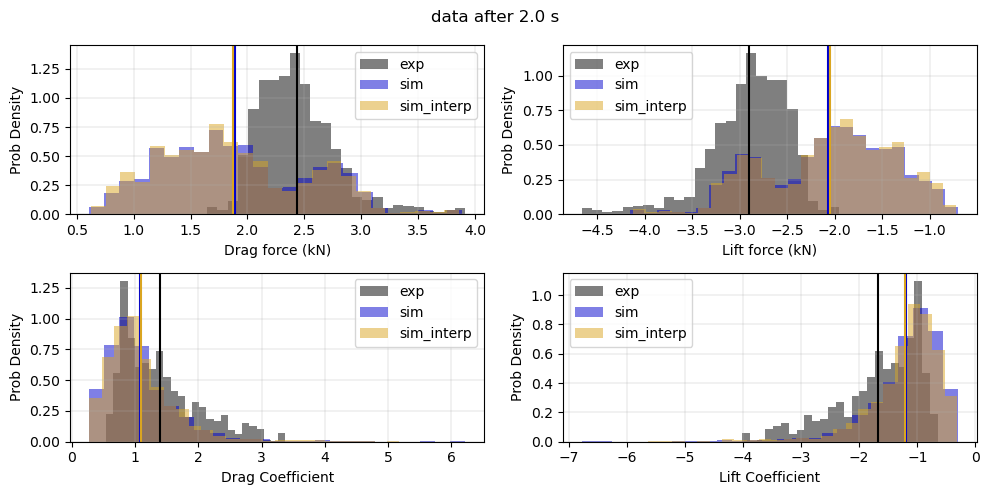

In [309]:
# histograms
plotdata = interp_sim_data[interp_sim_data.index > time_threshold]
plt_exp_data = exp_data[exp_data.index > time_threshold]

vars = ['Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
nbins = 25

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(2,2,figsize=[10,5]) #, dpi=300) #, sharey=True)
plt.suptitle(f'data after {time_threshold} s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):

statistics_list = []

for var,ax in zip(vars, axs.ravel()):
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > time_threshold]
        ax.hist(pltdata, bins=nbins, density=True, alpha=0.5, label=key, color=colors[key])
        ax.axvline(np.mean(pltdata.values), color=colors[key], label='')
        ax.set_xlabel(var)
        ax.legend()

        stats = {
            'Key': f"{key}",
            'Var': f"{var}",
            'Mean': np.mean(pltdata.values),
            'Median': np.median(pltdata.values),
            'Max': np.max(pltdata.values),
            'Min': np.min(pltdata.values),
            'Std Dev': np.std(pltdata.values)
        }
        statistics_list.append(stats)

for ax in axs.ravel():
    ax.grid(lw=0.25)
    ax.legend()
    ax.set_ylabel('Prob Density')

# # for ax in axs:
# axs[-1].set_xlabel('time [s]')

plt.tight_layout()

statistics_df = pd.DataFrame(statistics_list).set_index('Key')
statistics_df.round(3)

In [310]:
# compute flow metrics
def compute_TI(u,v,w):
    umag = (u**2 + v**2 + w**2)**0.5
    
    Iu = np.std(u, axis=0) / np.mean(umag, axis=0)
    Iv = np.std(v, axis=0) / np.mean(umag, axis=0)
    Iw = np.std(w, axis=0) / np.mean(umag, axis=0)

    return Iu, Iv, Iw

# Collect TI data for each dataset
TI_list = []  # Empty list to hold the results for the DataFrame

for key in alldata.keys():
    Iu, Iv, Iw = compute_TI(alldata[key]['u (m/s)'], alldata[key]['v (m/s)'], alldata[key]['w (m/s)'])
    
    # Append the results as a dictionary to the list
    TI_list.append({
        'Key': key,  # Use `key` to identify the dataset
        'Iu': round(Iu, 3),
        'Iv': round(Iv, 3),
        'Iw': round(Iw, 3)
    })

# Convert the list of dictionaries to a DataFrame
TI_df = pd.DataFrame(TI_list).set_index('Key')

# Print the resulting DataFrame
TI_df

,Iu,Iv,Iw
Key,,,
exp,0.204,0.227,0.075
sim,0.234,0.203,0.122
sim_interp,0.234,0.200,0.118


In [311]:
# Smooth high frequency region
def runningMeanFast(x, N):
    """
    Calculates the running mean of an array x over a window size N.

    Returns:
        np.ndarray: Smoothed signal
    """
    return np.convolve(x, np.ones(N)/N, mode='same') 

def compute_spectra(u, U_mean, height, fs, overlap):
    """
    Computes the normalized energy spectrum of a velocity time series `u`,
    smooths the high-frequency tail, and returns the normalized frequency
    and smoothed normalized power spectral density.

    Parameters:
        u (array-like): Time series of velocity fluctuations (1D)
        U_mean (float): Mean flow velocity (for normalization)
        height (float): Reference height (for normalization)
        fs (float): Sampling frequency [Hz]
        overlap (int): Number of samples to overlap in Welch’s method

    Returns:
        nf_U_corr (np.ndarray): Normalized frequency array
        nPxxf_mod_U_corr (list of np.ndarray): Concatenated original and smoothed
            normalized power spectral density
    """

    # Length of the input time series (used for FFT size and window)
    nblock = len(u)

    # Use a Hamming window for spectral estimation
    win = np.hamming(math.floor(nblock/10))

    # Convert u to a pandas Series for easier handling (e.g., dropna, stats)
    U_corr = pd.Series(u)
    # do I need to detrend this? - probably not bc of "detrend = constant" in welch function call

    # Standard deviation of the fluctuations (used to normalize PSD)
    u_std = U_corr.std()

    # Compute power spectral density using Welch's method
    f_U_corr, Pxxf_U_corr = welch(U_corr.dropna(), fs, window=win, noverlap=overlap, nfft=nblock, detrend='constant', return_onesided=True) # detrend constant removes mean (zero-mean segments)
    
    # Normalize frequency: non-dimensional frequency = f * z / U_mean
    nf_U_corr = f_U_corr*height/abs(U_mean)

    # Normalize power: dimensionless spectral density
    nPxxf_U_corr = (f_U_corr*Pxxf_U_corr)/u_std**2

    # Identify index where normalized frequency > 0.3 (start smoothing here)
    index_highfreq_U_corr = list(np.where([abs(nf_U_corr)>0.3]))

    # Extract the high-frequency tail to smooth
    nPxxf_smooth_U_corr = nPxxf_U_corr[index_highfreq_U_corr[0][0]:len(nPxxf_U_corr)]

    # Apply running mean to smooth the high-frequency region
    avg_window_size = int(nblock/6)
    nPxxf_smooth_U_corr = runningMeanFast(nPxxf_smooth_U_corr,avg_window_size) # 200)

    # Concatenate the low-frequency part (unsmoothed) with the smoothed tail
    # nPxxf_mod_U_corr = [nPxxf_U_corr[0:index_highfreq_U_corr[0][0]-1],nPxxf_smooth_U_corr]
    nPxxf_mod_U_corr = nPxxf_U_corr # without smoothing

    # return nf_U_corr, nPxxf_mod_U_corr
    return nf_U_corr, nPxxf_mod_U_corr

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_218928/4077353783.py:30: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")


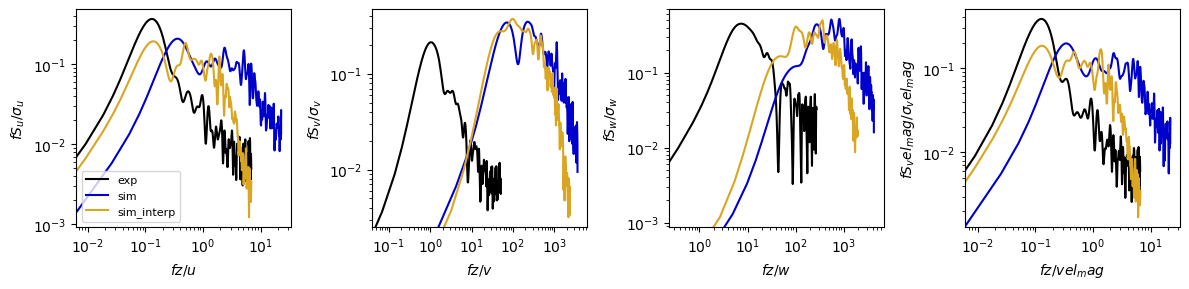

In [312]:
# spectra of flow
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['u','v','w','vel_mag']

nf_corr = {}; nPxxf_mod_corr = {}
U_mean = {}

for var in vars:
    U_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        U_mean[var][comp] = float(np.nanmean(alldata[var][comp+' (m/s)'].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp+' (m/s)'].values.squeeze(), U_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,4, figsize=[12,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_218928/3043309257.py:30: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")


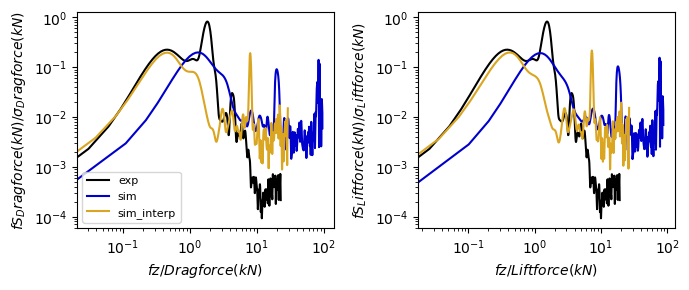

In [313]:
# spectra of loads
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['Drag force (kN)', 'Lift force (kN)']

nf_corr = {}; nPxxf_mod_corr = {}
comp_mean = {}

for var in vars:
    comp_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        comp_mean[var][comp] = float(np.nanmean(alldata[var][comp].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp].values.squeeze(), comp_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,2, figsize=[7,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()

In [314]:
# # first glance at drag and lift forces
# plt.style.use('default')
# time_threshold = 2.0 #12.0 # s

# vars = ['Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
# colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}
# keys = ['sim','sim_interp','exp']

# fig, axs = plt.subplots(2,2,figsize=[10,5],sharex=True) #, dpi=300) #, sharey=True)
# # plt.suptitle('u='+u+' m/s')
# # for n,var in enumerate(vars):
# for var,ax in zip(vars, axs.ravel()):
#     for key in keys:
#         pltdata = alldata[key][var][alldata[key][var].index > 2.0]
#         ax.plot(pltdata, label=key, color=colors[key])
#         ax.axvline(time_threshold, linestyle=':', color='k')
#         ax.set_ylabel(var)
#         # ax.legend()
#         # axs[0].set_xlim([15, 20])
#         # axs[0].set_ylim([0.0, 4.0])

# for ax in axs.ravel():
#     ax.grid(lw=0.25)
#     # ax.legend()

# for ax in axs[-1,:]:
#     ax.set_xlabel('time [s]')

# axs[-1,-1].legend()

# plt.tight_layout()

In [315]:
# # plot velocity signals
# fig, axs = plt.subplots(4,1, figsize=[8,6], sharex=True)

# comps = ['u','v','w','vel_mag']
# vars = ['sim','sim_interp','exp']
# # vars = ['exp']

# for comp,ax in zip(comps, axs.ravel()):
#     for var in vars:
#         ax.plot(alldata[var][comp+' (m/s)'], label=var, alpha=0.8, color=colors[var])
#         ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()

In [316]:
# # if needed for debugging: plot signal from h5 file and sonic
# import h5py

# turb_h5_fname = '/projects/pvopt/aps_dfd_2024/PVade/input/pct_constrained_turb_ny154_nz38_sonic1_30s_u9.0_50Hz.h5'
# sim_turb_data = {}

# with h5py.File(turb_h5_fname, "r") as fp:
#     for key, val in fp.items():
#         print(key, val.shape, val.dtype)

#     t_fp = fp["time_index"][:]
#     y_fp = fp["y_coordinates"][:]
#     z_fp = fp["z_coordinates"][:]

#     # comp="u"
#     # fig, ax = plt.subplots()
#     # plt.suptitle('pyconturb flowfield')
#     # plt.imshow(fp[comp][0, :, :],  # imshow requires nz-ny slice
#     #             origin='lower',  # smallest y-z in lower left, not upper left
#     #             extent=[y_fp[0], y_fp[-1], z_fp[0], z_fp[-1]],  # lateral and vertical limits
#     #             interpolation='bilinear',
#     #             cmap='coolwarm')  # image smoothing
#     # plt.colorbar(label=comp)

#     sim_turb_data["u"] = fp["u"][:, :, :]
#     sim_turb_data["v"] = fp["v"][:, :, :]
#     sim_turb_data["w"] = fp["w"][:, :, :]

# jp = int(np.argmin(np.abs(y_fp - yloc)))
# kp = int(np.argmin(np.abs(z_fp - zloc)))
# # print(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')

# fig, axs = plt.subplots(3,1, figsize=[8,6], sharex=True)
# plt.suptitle(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')
# for comp,ax in zip(['u','v','w'], axs.ravel()):
#     ax.plot(t_fp,sim_turb_data[comp][:,kp,jp], label='pyconturb')
#     ax.plot(alldata['sim'][comp+' (m/s)'], label='pvade at inlet')
#     ax.plot(alldata['exp'][comp+' (m/s)'], 'k', label='experimental')
#     ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()